In [589]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [590]:
# loading the dataset
df = pd.read_csv("data/raw/IBM.CSV")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- Loaded the CSV file successfully.
- Inspected the first few rows to understand the dataset structure.
- Each row appears to represent one customer.
- The columns describe customer ID, demographic details, subscribed services, billing information such as monthly and total charges, and the target variable Churn, which indicates whether the customer left the telecom service.

In [591]:
df.shape

(7043, 21)

- The dataset has 7043 obsevations.
- It has 21 features.

In [592]:
#df.columns.tolist()

In [593]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [594]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

- No columns have have missing values
- But TotalCharges datatype is string

In [595]:
#df.isnull().sum()

In [596]:
# to check for empty strings in the dataset
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- Here TotalCharges have blank spaces.

In [597]:
# Converting TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

- TotalCharges was stored as an object column because some rows contained blank values.
- These blanks were treated as missing values and the column was converted to numeric format.

In [598]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [599]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [600]:
# how many customers have churned?
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [601]:
# percentage of customers who have churned
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

- The target variable Churn is moderately imbalanced.
- Around 73.46% of customers did not churn, while 26.54% churned.

In [602]:
#separating numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\MOUSUMI\AppData\Local\Temp\ipykernel_16028\89917568.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


- Numerical features include SeniorCitizen, tenure, MonthlyCharges, TotalCharges.
- Categorical features include contract, internet service, payment method, etc.

In [603]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head())


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                   

In [604]:
# study the distribution of numerical columns
df[num_cols].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


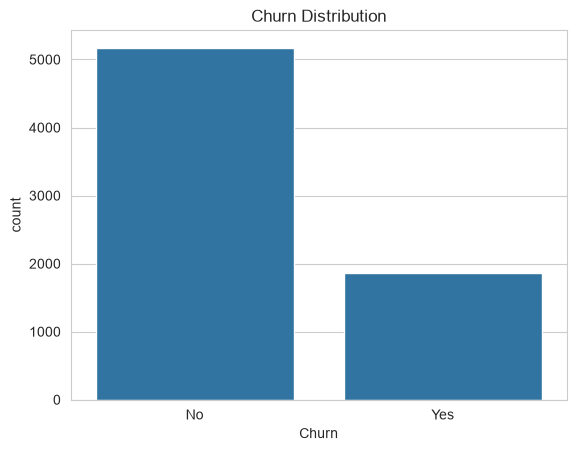

In [605]:
# Target variable distribution
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

In [606]:
# churn by contract
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [607]:
# Churn by internet service
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [608]:
#Churn by payment method
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


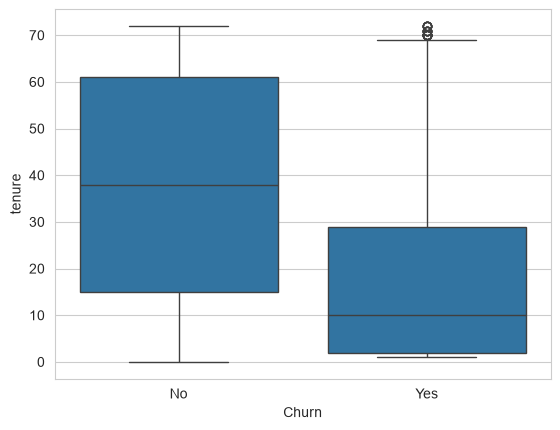

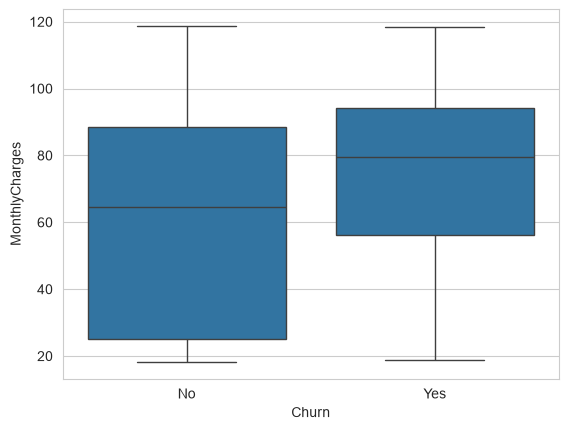

In [609]:
# studying numerical features against churn
sns.boxplot(data=df, x="Churn", y="tenure")
plt.show()

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.show()

- Here, I analyzed tenure and MonthlyCharges against Churn to identify whether churn is more common among customers with lower or higher tenure and monthly charges.
- I observed that customers with lower tenure are more likely to churn, and churn is also higher among customers with higher monthly charges.

## Business problem

- *Target* which predict whether a Customer will churn or not.
- *Binary Classification* problem
- *Business Use:* Help telecome companies identify high-risk customers and take retention actions early.

## Cleaning the IBM Dataset

In [610]:
df_clean = df.copy()

In [611]:
df_clean.shape

(7043, 21)

In [612]:
df_clean.columns = df_clean.columns.str.strip()

In [613]:
df_clean["customerID"].head()


0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: str

In [614]:
df_clean["customerID"].nunique()

7043

In [615]:
# Dropping the CustomerID, since it is usually just an identifier and does not provide any predictive power for the model.
df_clean = df_clean.drop(columns=["customerID"])

In [616]:
df_clean.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [617]:
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [618]:
df_clean[df_clean["TotalCharges"].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [619]:
df_clean[df_clean["tenure"] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [620]:
# filling the missing TotalCharges with 0, since these customers have not been charged anything yet.
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [621]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

In [622]:
df_clean.shape

(7043, 20)

In [623]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- First, I identified the rows where TotalCharges was missing and examined the corresponding tenure values. These rows had tenure = 0, which suggests that the customers are newly joined.
- Since TotalCharges is a cumulative billing feature, it is reasonable that customers with tenure = 0 have not yet accumulated any charges. Therefore, the missing values in TotalCharges were imputed with 0.

In [624]:
for col in df_clean.select_dtypes(include=["object", "string"]).columns:
    print(col, df_clean[col].astype(str).str.strip().equals(df_clean[col].astype(str)))

gender True
Partner True
Dependents True
PhoneService True
MultipleLines True
InternetService True
OnlineSecurity True
OnlineBackup True
DeviceProtection True
TechSupport True
StreamingTV True
StreamingMovies True
Contract True
PaperlessBilling True
PaymentMethod True
Churn True


## Exploratory Data Analysis (EDA)

In [625]:
df_eda = df_clean.copy()

**Churn Distribution**

In [626]:
df_eda["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [627]:
df_eda["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

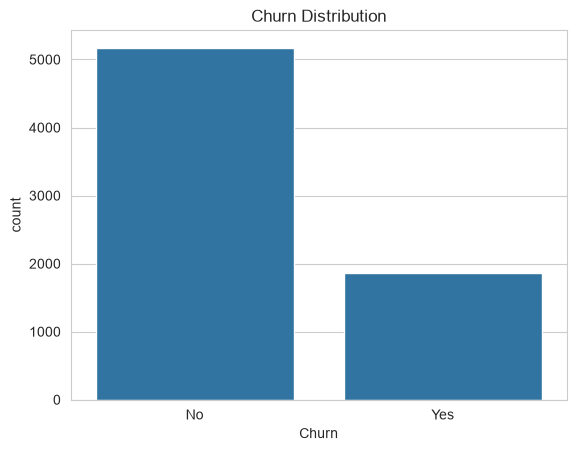

In [628]:
sns.countplot(data=df_eda, x="Churn")
plt.title("Churn Distribution")
plt.show()

- The target variable Churn is moderately imbalanced.
- Most customers did not churn, while a smaller portion churned.

**Churn vs Contract type**

In [629]:
pd.crosstab(df_eda["Contract"], df_eda["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


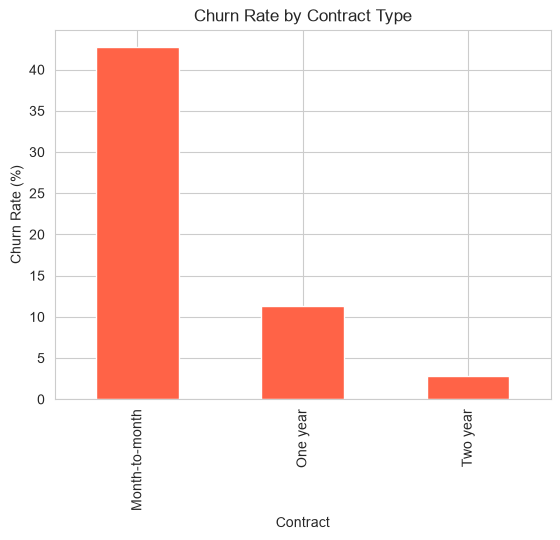

In [630]:
contract_churn = pd.crosstab(df_eda["Contract"], df_eda["Churn"], normalize="index") * 100
contract_churn["Yes"].sort_values(ascending=False).plot(kind="bar", color="tomato")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Contract Type")
plt.show()

- Customers with month-to-month contracts show much higher churn than customers with one-year or two-year contracts.

**Churn vs Tenure**

In [631]:
#sns.boxplot(data=df_eda, x="Churn", y="tenure")
#plt.title("Tenure vs Churn")
#plt.show()

In [632]:
tenure_bins = pd.cut(
    df_eda["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

pd.crosstab(tenure_bins, df_eda["Churn"], normalize="index") * 100

Churn,No,Yes
tenure,,
0-12,52.561757,47.438243
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


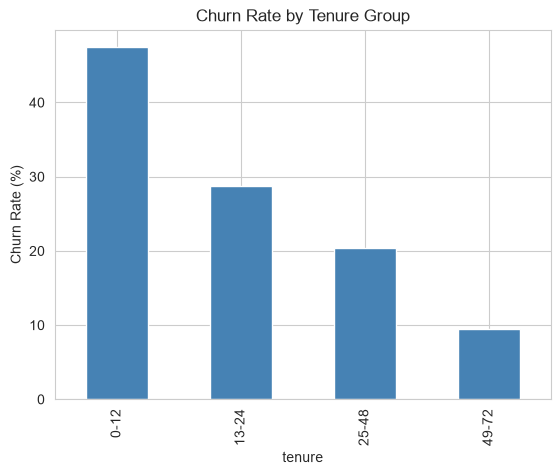

In [633]:
tenure_churn = pd.crosstab(tenure_bins, df_eda["Churn"], normalize="index") * 100
tenure_churn["Yes"].plot(kind="bar", color="steelblue")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Group")
plt.show()

- Customers with lower tenure are more likely to churn, suggesting that new or early-stage customers are at higher risk.

**Churn vs Monthly Charges**

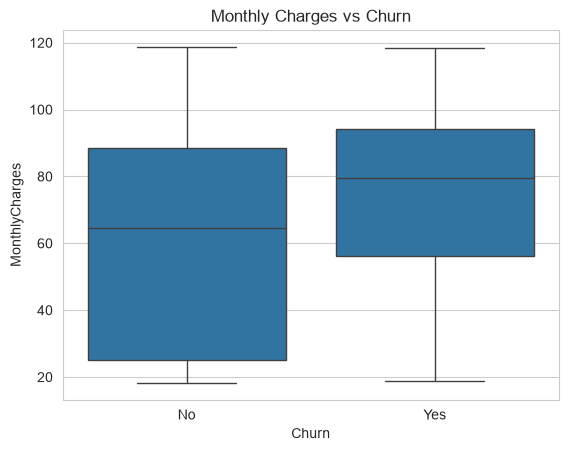

In [634]:
sns.boxplot(data=df_eda, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

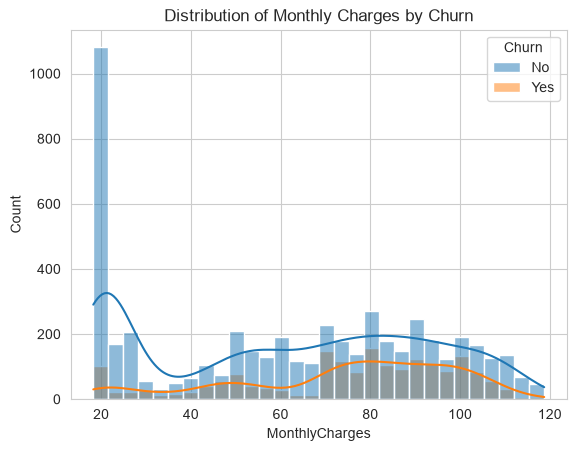

In [635]:
sns.histplot(data=df_eda, x="MonthlyCharges", hue="Churn", kde=True, bins=30)
plt.title("Distribution of Monthly Charges by Churn")
plt.show()

- Customers with higher monthly charges appear more likely to churn.

**Churn vs Payment Method**

In [636]:
pd.crosstab(df_eda["PaymentMethod"], df_eda["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


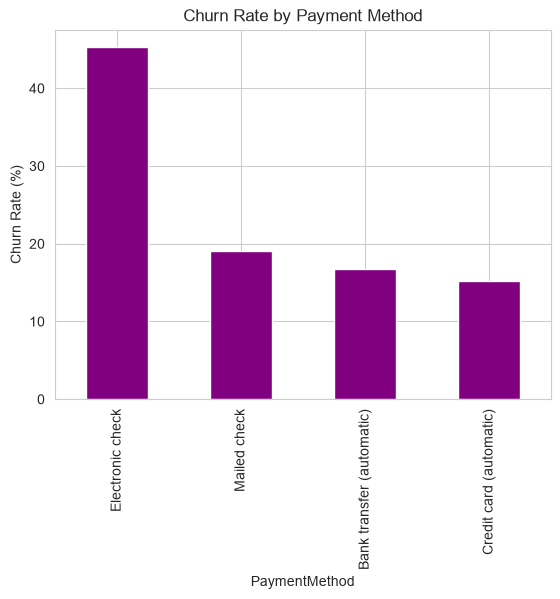

In [637]:
payment_churn = pd.crosstab(df_eda["PaymentMethod"], df_eda["Churn"], normalize="index") * 100
payment_churn["Yes"].sort_values(ascending=False).plot(kind="bar", color="purple")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Payment Method")
plt.show()

- Customers using electronic check show a higher churn rate than customers using automatic payment methods.

**Churn vs Internet Service**

In [638]:
pd.crosstab(df_eda["InternetService"], df_eda["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


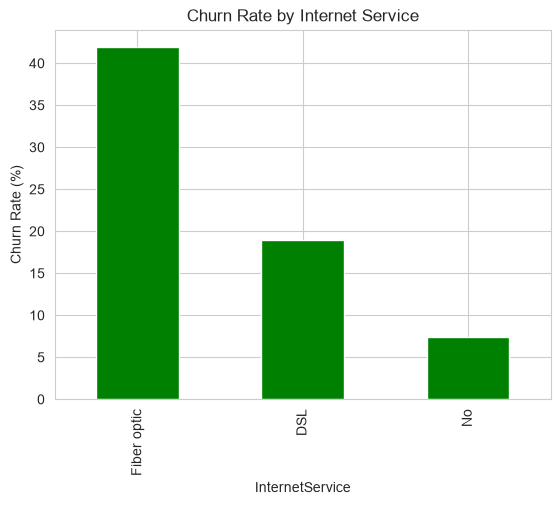

In [639]:
internet_churn = pd.crosstab(df_eda["InternetService"], df_eda["Churn"], normalize="index") * 100
internet_churn["Yes"].sort_values(ascending=False).plot(kind="bar", color="green")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Internet Service")
plt.show()

- Fiber optic customers appear to have a higher churn rate compared to DSL customers and customers without internet service.

**Churn vs Senior Citizen**

In [640]:
pd.crosstab(df_eda["SeniorCitizen"], df_eda["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


**Churn vs Paperless Billing**

In [641]:
pd.crosstab(df_eda["PaperlessBilling"], df_eda["Churn"], normalize="index") * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


- The churn variable is moderately imbalanced.
- Customers with month-to-month contracts have the highest churn rate.
- Customers with lower tenure are more likely to churn.
- Customers with higher monthly charges show higher churn risk.
- Electronic check users have higher churn than customers using automatic payment methods.
- Fiber optic customers appear to churn more than DSL and no-internet customers.

In [642]:
# Create a modeling copy
df_model = df_clean.copy()
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [643]:
# Define the target y
y = df_model["Churn"].map({"No": 0, "Yes": 1})
y.head()


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [644]:
# Define the input features X
X = df_model.drop(columns=["Churn"])
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [645]:
# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [646]:
# Identify numerical and categorical features
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [647]:
# Split train and test data using stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [648]:
# Check split shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


In [649]:
# Verify churn ratio in train and test
print("Train churn ratio:")
print(y_train.value_counts(normalize=True))

print("\nTest churn ratio:")
print(y_test.value_counts(normalize=True))

Train churn ratio:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test churn ratio:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [650]:
# Import preprocessing tools, Create the preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [651]:
# Fit on training data and transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [652]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5634, 45)
Processed X_test shape: (1409, 45)


In [653]:
# View processed feature names

feature_names = preprocessor.get_feature_names_out()
print("Total processed features:", len(feature_names))
print(feature_names[:20])

Total processed features: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service']


- The cleaned dataset was separated into input features X and target variable y, where Churn was encoded as 0 for non-churn and 1 for churn.
- Numerical and categorical features were identified separately because they require different preprocessing methods.
- The dataset was split into training and testing sets using stratified sampling so that the churn distribution remains similar in both sets.
- Numerical features were scaled using StandardScaler, while categorical features were transformed using OneHotEncoder.
- The preprocessing steps were fitted only on the training data and then applied to the test data to avoid data leakage.

## Train a baseline model first

In [654]:
#X.head()
#y.head()

In [655]:
#print(X.shape)
#print(y.value_counts())

In [656]:
#split the data into train and test
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(
#   X, y,
#    test_size=0.2,
#    random_state=42,
#    stratify=y
#)

In [657]:
#print(X_train.shape, X_test.shape)
#print(y_train.value_counts(normalize=True))
#print(y_test.value_counts(normalize=True))

In [658]:
# Identify numerical and categorical columns in the training set
#num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
#cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

#print("Numerical columns:", num_cols)
#print("Categorical columns:", cat_cols)

In [659]:
#build preprocessing pipelines
#from sklearn.pipeline import Pipeline
#from sklearn.compose import ColumnTransformer
#from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical pipeline

#num_pipeline = Pipeline([
#    ("imputer", SimpleImputer(strategy="median")),
#    ("scaler", StandardScaler())
#])

# Categorical pipeline

#cat_pipeline = Pipeline([
#    ("imputer", SimpleImputer(strategy="most_frequent")),
#    ("onehot", OneHotEncoder(handle_unknown="ignore"))
#])

#preprocessor = ColumnTransformer([
#    ("num", num_pipeline, num_cols),
#    ("cat", cat_pipeline, cat_cols)
#])

In [660]:
# create the Logistic Regression baseline model

from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)

In [661]:
# train the baseline model
baseline_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [662]:
# make predictions
y_pred = baseline_model.predict(X_test_processed)
y_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

In [663]:
# evaluate the baseline properly

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1-score:", f1_score(y_test, y_pred, pos_label=1))
print("ROC-AUC:", roc_auc_score((y_test == 1).astype(int), y_proba))

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1-score: 0.6040462427745664
ROC-AUC: 0.8421349040274871


In [664]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[926 109]
 [165 209]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



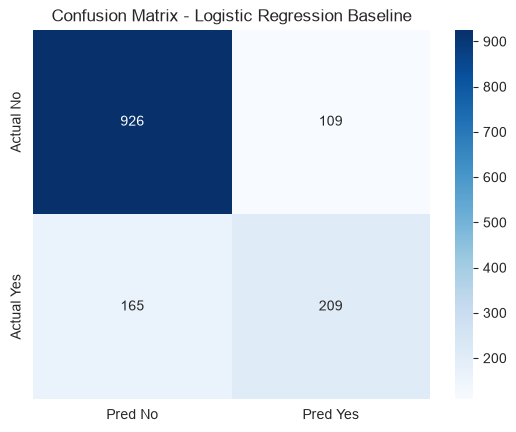

In [665]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred No", "Pred Yes"],
            yticklabels=["Actual No", "Actual Yes"])
plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.show()

## Training Random Forest and XGBoost

In [666]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [667]:
#tree_num_pipeline = Pipeline([
#    ("imputer", SimpleImputer(strategy="median"))
#])

#tree_cat_pipeline = Pipeline([
#    ("imputer", SimpleImputer(strategy="most_frequent")),
#    ("onehot", OneHotEncoder(handle_unknown="ignore"))
#])

#tree_preprocessor = ColumnTransformer([
#    ("num", tree_num_pipeline, num_cols),
#    ("cat", tree_cat_pipeline, cat_cols)
#])

In [668]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [669]:
# create the Random Forest model

rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

In [670]:
rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [671]:
rf_pred = rf_model.predict(X_test_processed)
rf_proba = rf_model.predict_proba(X_test_processed)[:, 1]

In [672]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, pos_label=1))
print("Recall:", recall_score(y_test, rf_pred, pos_label=1))
print("F1-score:", f1_score(y_test, rf_pred, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Random Forest
Accuracy: 0.7984386089425124
Precision: 0.6607142857142857
Recall: 0.4946524064171123
F1-score: 0.5657492354740061
ROC-AUC: 0.8350331964142705


In [673]:
#create the XGBoost model

xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

In [674]:
xgb_model.fit(X_train_processed, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [675]:
xgb_pred = xgb_model.predict(X_test_processed)
xgb_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

In [676]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, pos_label=1))
print("Recall:", recall_score(y_test, xgb_pred, pos_label=1))
print("F1-score:", f1_score(y_test, xgb_pred, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

XGBoost
Accuracy: 0.7984386089425124
Precision: 0.6490066225165563
Recall: 0.5240641711229946
F1-score: 0.5798816568047337
ROC-AUC: 0.8418597742127154


In [677]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, pos_label=1),
        precision_score(y_test, rf_pred, pos_label=1),
        precision_score(y_test, xgb_pred, pos_label=1)
    ],
    "Recall": [
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, rf_pred, pos_label=1),
        recall_score(y_test, xgb_pred, pos_label=1)
    ],
    "F1-score": [
        f1_score(y_test, y_pred, pos_label=1),
        f1_score(y_test, rf_pred, pos_label=1),
        f1_score(y_test, xgb_pred, pos_label=1)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
})

results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
2,XGBoost,0.798439,0.649007,0.524064,0.579882,0.841860
1,Random Forest,0.798439,0.660714,0.494652,0.565749,0.835033


## Handle class imbalance

### Threshold tuning first

**Tune threshold for Logistic Regression**

In [678]:
#from sklearn.linear_model import LogisticRegression

#X_train_processed = preprocessor.fit_transform(X_train)
#X_test_processed = preprocessor.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)

y_prob = lr.predict_proba(X_test_processed)[:, 1]
y_pred = lr.predict(X_test_processed)

In [679]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1-score": f1_score(y_test, y_pred_t),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.30,0.749468,0.519337,0.754011,0.615049,0.842135
1,0.35,0.764372,0.543210,0.705882,0.613953,0.842135
2,0.40,0.777147,0.568182,0.668449,0.614251,0.842135
3,0.45,0.789922,0.602094,0.614973,0.608466,0.842135
4,0.50,0.805536,0.657233,0.558824,0.604046,0.842135
5,0.55,0.799148,0.678431,0.462567,0.550079,0.842135
6,0.60,0.799148,0.717703,0.401070,0.514580,0.842135


- Threshold tuning was performed to improve churn detection beyond the default 0.5 cutoff.
- Lowering the threshold increased recall, meaning more actual churners were identified.
- Among the tested thresholds, 0.40 produced the best balance between precision and recall, with the highest F1-score (0.614) and a substantially improved recall (0.668).
- Therefore, 0.40 was selected as the business-preferred threshold for the churn prediction model.

In [680]:
# class-weighted Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_bal_pipeline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

lr_bal_pipeline.fit(X_train_processed, y_train)

y_pred_bal = lr_bal_pipeline.predict(X_test_processed)
y_prob_bal = lr_bal_pipeline.predict_proba(X_test_processed)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall:", recall_score(y_test, y_pred_bal))
print("F1-score:", f1_score(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bal))

Accuracy: 0.7381121362668559
Precision: 0.504302925989673
Recall: 0.7834224598930482
F1-score: 0.6136125654450262
ROC-AUC: 0.8416388953473353


In [681]:
#Random Forest with class weights
weighted_rf =  RandomForestClassifier(
        n_estimators=200,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

weighted_rf.fit(X_train_processed, y_train)
weighted_rf_pred = weighted_rf.predict(X_test_processed)
weighted_rf_proba = weighted_rf.predict_proba(X_test_processed)[:, 1]

In [682]:
print("Weighted Random Forest")
print("Accuracy:", accuracy_score(y_test, weighted_rf_pred))
print("Precision:", precision_score(y_test, weighted_rf_pred, pos_label=1))
print("Recall:", recall_score(y_test, weighted_rf_pred, pos_label=1))
print("F1-score:", f1_score(y_test, weighted_rf_pred, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, weighted_rf_proba))

Weighted Random Forest
Accuracy: 0.7558552164655784
Precision: 0.5298804780876494
Recall: 0.7112299465240641
F1-score: 0.6073059360730594
ROC-AUC: 0.8325079438890182


In [683]:
print(confusion_matrix(y_test, weighted_rf_pred))
print(classification_report(y_test, weighted_rf_pred))

[[799 236]
 [108 266]]
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [684]:
#XGBoost with imbalance handling
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(scale_pos_weight)

2.768561872909699


In [685]:
weighted_xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    )

weighted_xgb.fit(X_train_processed, y_train)
weighted_xgb_pred = weighted_xgb.predict(X_test_processed)
weighted_xgb_proba = weighted_xgb.predict_proba(X_test_processed)[:, 1]

In [686]:
print("Weighted XGBoost")
print("Accuracy:", accuracy_score(y_test, weighted_xgb_pred))
print("Precision:", precision_score(y_test, weighted_xgb_pred, pos_label=1))
print("Recall:", recall_score(y_test, weighted_xgb_pred, pos_label=1))
print("F1-score:", f1_score(y_test, weighted_xgb_pred, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, weighted_xgb_proba))

Weighted XGBoost
Accuracy: 0.7579843860894251
Precision: 0.52994555353902
Recall: 0.7807486631016043
F1-score: 0.6313513513513513
ROC-AUC: 0.8385440078534708


In [687]:
print(confusion_matrix(y_test, weighted_xgb_pred))
print(classification_report(y_test, weighted_xgb_pred))

[[776 259]
 [ 82 292]]
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [688]:
# Gathering all the model results for comparison
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Weighted Random Forest",
        "Weighted XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, weighted_rf_pred),
        accuracy_score(y_test, weighted_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, weighted_rf_pred),
        precision_score(y_test, weighted_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, weighted_rf_pred),
        recall_score(y_test, weighted_xgb_pred)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, weighted_rf_pred),
        f1_score(y_test, weighted_xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba),
        roc_auc_score(y_test, weighted_rf_proba),
        roc_auc_score(y_test, weighted_xgb_proba)
    ]
})

final_results.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,Weighted XGBoost,0.757984,0.529946,0.780749,0.631351,0.838544
3,Weighted Random Forest,0.755855,0.529880,0.711230,0.607306,0.832508
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
2,XGBoost,0.798439,0.649007,0.524064,0.579882,0.841860
1,Random Forest,0.798439,0.660714,0.494652,0.565749,0.835033


In [689]:
final_results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
2,XGBoost,0.798439,0.649007,0.524064,0.579882,0.841860
4,Weighted XGBoost,0.757984,0.529946,0.780749,0.631351,0.838544
1,Random Forest,0.798439,0.660714,0.494652,0.565749,0.835033
3,Weighted Random Forest,0.755855,0.529880,0.711230,0.607306,0.832508


- Final model (champion): Weighted XGBoost
- Baseline/challenger: Logistic Regression

- The final model was selected based on F1-score, recall, and ROC-AUC rather than accuracy alone. Since churn prediction is a business-sensitive classification problem, identifying customers likely to leave is more important than maximizing overall accuracy. Among all evaluated models, Weighted XGBoost achieved the highest F1-score (0.631) and the highest recall (0.781), while maintaining a strong ROC-AUC (0.839). Therefore, Weighted XGBoost was selected as the final model for churn prediction.

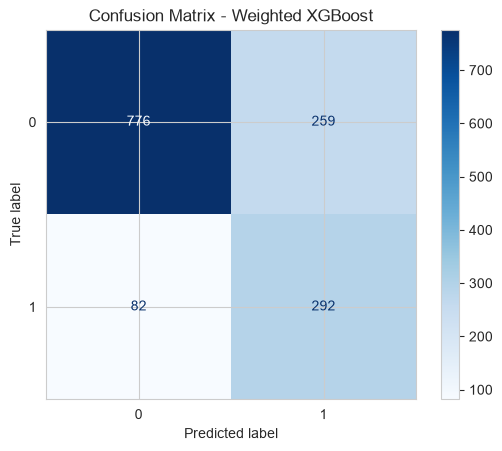

In [690]:
# Show confusion matrix for the final model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, weighted_xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Weighted XGBoost")
plt.show()

In [691]:
#Do threshold tuning on the final model
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for t in thresholds:
    pred_t = (weighted_xgb_proba >= t).astype(int)
    print(f"Threshold: {t}")
    print("Precision:", round(precision_score(y_test, pred_t), 4))
    print("Recall   :", round(recall_score(y_test, pred_t), 4))
    print("F1-score :", round(f1_score(y_test, pred_t), 4))
    print("-" * 30)

Threshold: 0.3
Precision: 0.4524
Recall   : 0.877
F1-score : 0.5969
------------------------------
Threshold: 0.35
Precision: 0.4698
Recall   : 0.8529
F1-score : 0.6059
------------------------------
Threshold: 0.4
Precision: 0.4866
Recall   : 0.8262
F1-score : 0.6125
------------------------------
Threshold: 0.45
Precision: 0.5084
Recall   : 0.8048
F1-score : 0.6232
------------------------------
Threshold: 0.5
Precision: 0.5299
Recall   : 0.7807
F1-score : 0.6314
------------------------------
Threshold: 0.55
Precision: 0.541
Recall   : 0.7406
F1-score : 0.6253
------------------------------
Threshold: 0.6
Precision: 0.5527
Recall   : 0.6872
F1-score : 0.6126
------------------------------


- I selected Weighted XGBoost as the final model because it achieved the best F1-score and highest recall, which are more important than raw accuracy in churn prediction.
- I kept Logistic Regression as the benchmark because it is simpler and more interpretable.

## Using SHAP for Explainability

In [692]:
import shap
import pandas as pd
import numpy as np

In [693]:
shap.initjs()

In [694]:
#inspect stored feature names
print("Preprocessor fitted on:")
print(preprocessor.feature_names_in_)

print("\nCurrent X_train columns:")
print(X_train.columns.tolist())

Preprocessor fitted on:
['gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure' 'PhoneService'
 'MultipleLines' 'InternetService' 'OnlineSecurity' 'OnlineBackup'
 'DeviceProtection' 'TechSupport' 'StreamingTV' 'StreamingMovies'
 'Contract' 'PaperlessBilling' 'PaymentMethod' 'MonthlyCharges'
 'TotalCharges']

Current X_train columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [695]:
print(len(preprocessor.feature_names_in_))
print(len(X_train.columns))

19
19


In [696]:
feature_names = preprocessor.get_feature_names_out(preprocessor.feature_names_in_)

In [697]:
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_train_shap = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_shap = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

In [698]:
print(len(feature_names))
print(X_train_processed.shape)
print(X_test_processed.shape)

45
(5634, 45)
(1409, 45)


In [699]:
import shap
import numpy as np

explainer = shap.TreeExplainer(weighted_xgb)
X_test_sample = X_test_shap.sample(200, random_state=42)
shap_values = explainer(X_test_sample)

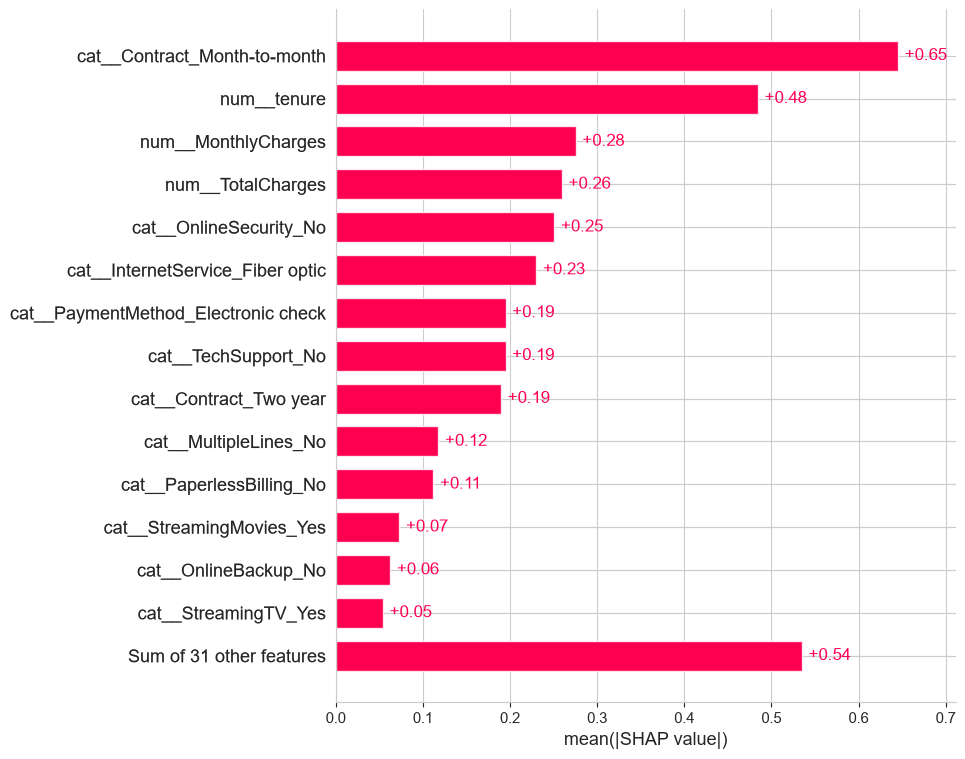

In [700]:
shap.plots.bar(shap_values, max_display=15)

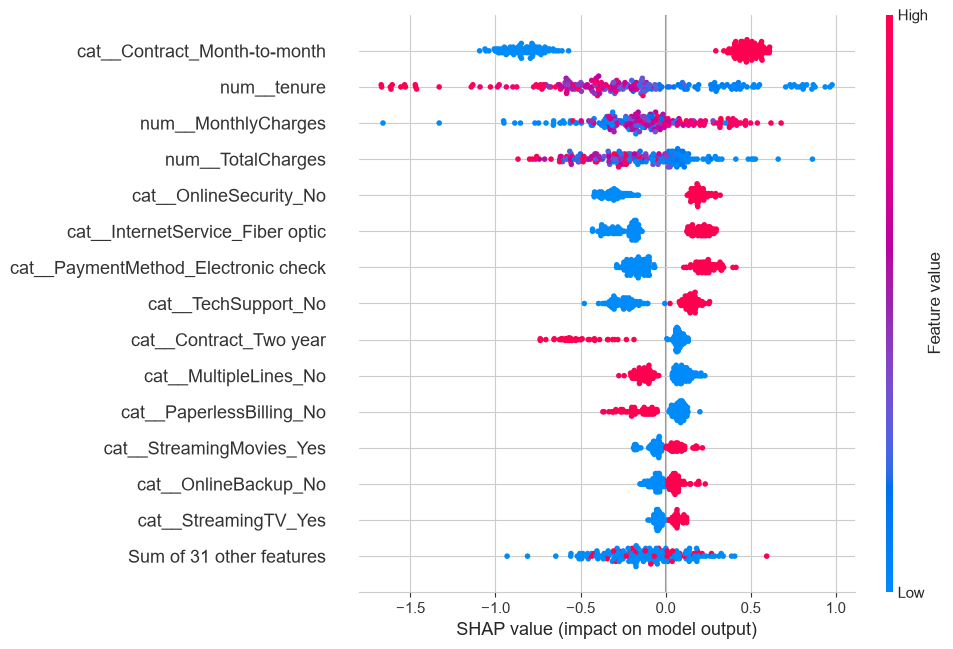

In [701]:
shap.plots.beeswarm(shap_values, max_display=15)

In [702]:
[f for f in feature_names if "Contract" in f]
[f for f in feature_names if "MonthlyCharges" in f]
[f for f in feature_names if "tenure" in f]
[f for f in feature_names if "InternetService" in f]

['cat__InternetService_DSL',
 'cat__InternetService_Fiber optic',
 'cat__InternetService_No']

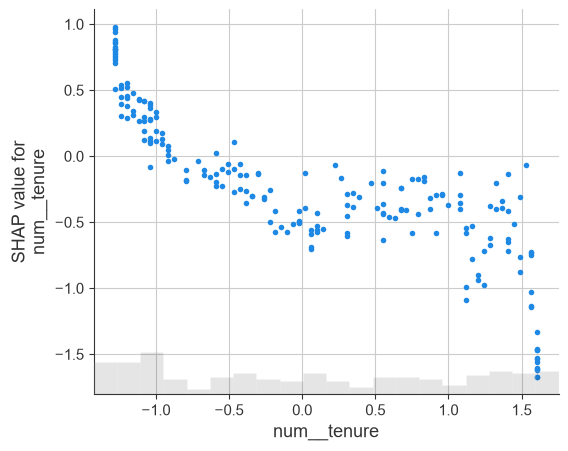

In [703]:
shap.plots.scatter(shap_values[:, "num__tenure"])

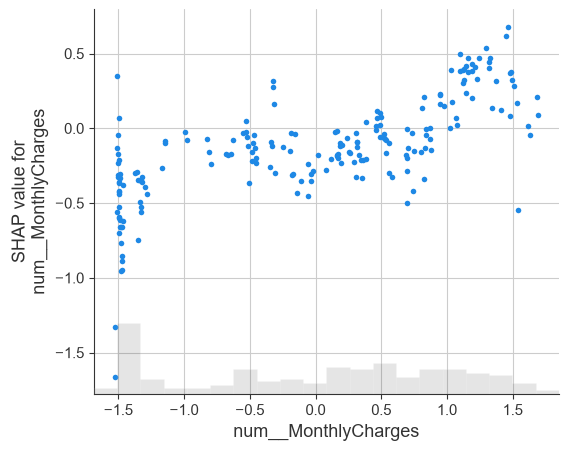

In [704]:
shap.plots.scatter(shap_values[:, "num__MonthlyCharges"])

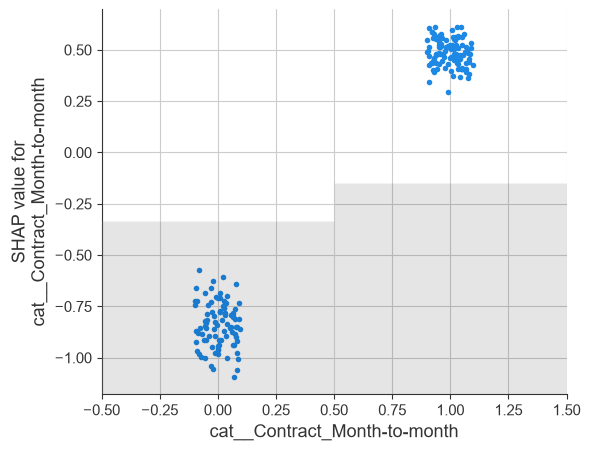

In [705]:
shap.plots.scatter(shap_values[:, "cat__Contract_Month-to-month"])

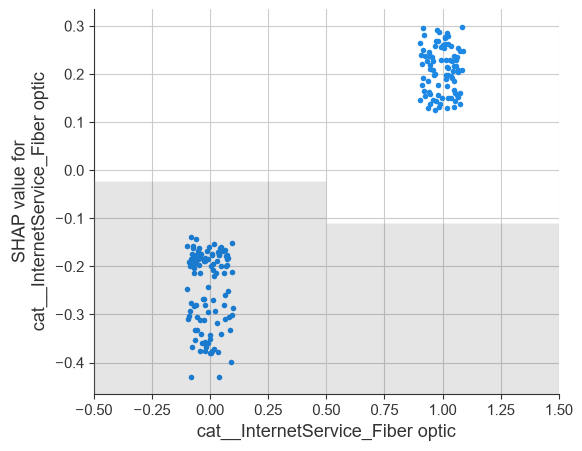

In [706]:
shap.plots.scatter(shap_values[:, "cat__InternetService_Fiber optic"])

In [707]:
shap_importance = pd.DataFrame({
    "feature": X_test_sample.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(15)

,feature,mean_abs_shap
36,cat__Contract_Month-to-month,0.645403
1,num__tenure,0.484610
2,num__MonthlyCharges,0.275407
3,num__TotalCharges,0.259615
18,cat__OnlineSecurity_No,0.250917
16,cat__InternetService_Fiber optic,0.230184
43,cat__PaymentMethod_Electronic check,0.194964
27,cat__TechSupport_No,0.194923
38,cat__Contract_Two year,0.189767
12,cat__MultipleLines_No,0.117815


In [708]:
#explain one customer prediction
#Now move from global explanation to local explanation.

test_results = X_test.copy()
test_results["true_churn"] = y_test.values
test_results["pred_prob"] = weighted_xgb_proba
test_results["pred_label"] = weighted_xgb_pred

In [709]:
high_risk_idx = test_results["pred_prob"].sort_values(ascending=False).index[0]
high_risk_idx

np.int64(3380)

In [710]:
customer_row = X_test_shap.loc[[high_risk_idx]]
customer_shap = explainer(customer_row)

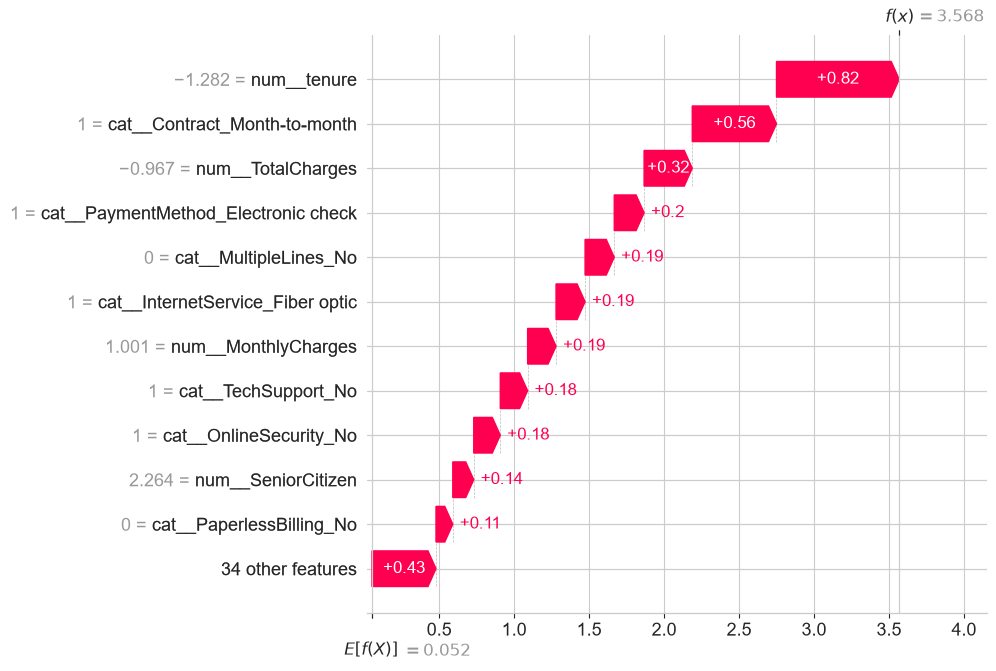

In [711]:
shap.plots.waterfall(customer_shap[0], max_display=12)

In [712]:
X_test.loc[high_risk_idx]

gender                          Male
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  95.1
TotalCharges                    95.1
Name: 3380, dtype: object

In [713]:
test_results.loc[high_risk_idx, ["pred_prob", "pred_label", "true_churn"]]

pred_prob     0.972567
pred_label    1.000000
true_churn    1.000000
Name: 3380, dtype: float64

- This customer was predicted as high churn risk.
- The main reasons were month-to-month contract, high monthly charges, and short tenure.
- Long tenure or automatic payment would have reduced churn risk, but this customer did not have those stabilizing factors.

- Contract_Month-to-month strongly increases churn risk.
- Higher MonthlyCharges tend to push customers toward churn.
- Longer tenure reduces churn risk.
- Fiber optic customers appear more churn-prone than some other service groups.

## Build a retention recommendation layer

In [714]:
test_results = X_test.copy()
test_results["true_churn"] = y_test.values
test_results["pred_prob"] = weighted_xgb_proba
test_results["pred_label"] = weighted_xgb_pred

test_results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,true_churn,pred_prob,pred_label
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.012071,0
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.943188,1
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.200753,0
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.582877,1
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.009277,0


In [715]:
def assign_risk_segment(prob):
    if prob >= 0.70:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    else:
        return "Low"

test_results["risk_segment"] = test_results["pred_prob"].apply(assign_risk_segment)

In [716]:
high_charge_cutoff = X_train["MonthlyCharges"].quantile(0.75)
low_tenure_cutoff = 12

print("High charge cutoff:", high_charge_cutoff)
print("Low tenure cutoff:", low_tenure_cutoff)

High charge cutoff: 90.0
Low tenure cutoff: 12


In [717]:
def recommend_retention_action(row):
    actions = []
    reasons = []

    # Low risk customers do not need immediate intervention
    if row["pred_prob"] < 0.40:
        return pd.Series({
            "primary_action": "Monitor only",
            "reason": "Low predicted churn probability",
            "all_actions": "Monitor only"
        })

    # Rule 1: month-to-month customers
    if row["Contract"] == "Month-to-month":
        actions.append("Offer 1-year or 2-year contract discount")
        reasons.append("Customer is on a month-to-month contract")

    # Rule 2: high monthly charges
    if row["MonthlyCharges"] >= high_charge_cutoff:
        actions.append("Offer pricing review or bundle discount")
        reasons.append("Customer has relatively high monthly charges")

    # Rule 3: low tenure / new customer
    if row["tenure"] <= low_tenure_cutoff:
        actions.append("Schedule onboarding or retention support call")
        reasons.append("Customer has low tenure and may be less loyal")

    # Rule 4: no tech support
    if row["TechSupport"] == "No" and row["InternetService"] != "No":
        actions.append("Offer free tech support trial")
        reasons.append("Customer does not currently have tech support")

    # Rule 5: electronic check users
    if row["PaymentMethod"] == "Electronic check":
        actions.append("Promote autopay discount or easier payment option")
        reasons.append("Electronic check users showed higher churn in EDA")

    # Rule 6: fiber optic customers with high charges
    if row["InternetService"] == "Fiber optic" and row["MonthlyCharges"] >= high_charge_cutoff:
        actions.append("Review service quality and offer internet bundle")
        reasons.append("Fiber optic customer with high charges may be price-sensitive")

    # Fallback
    if not actions:
        actions.append("General loyalty outreach")
        reasons.append("Customer is at risk but no specific rule was triggered")

    return pd.Series({
        "primary_action": actions[0],
        "reason": "; ".join(reasons),
        "all_actions": " | ".join(actions[:3])  # keep top few actions only
    })

In [718]:
recommendations = test_results.apply(recommend_retention_action, axis=1)
test_results = pd.concat([test_results, recommendations], axis=1)

test_results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,true_churn,pred_prob,pred_label,risk_segment,primary_action,reason,all_actions
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.012071,0,Low,Monitor only,Low predicted churn probability,Monitor only
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.943188,1,High,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...,Offer 1-year or 2-year contract discount | Off...
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.200753,0,Low,Monitor only,Low predicted churn probability,Monitor only
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.582877,1,Medium,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Elec...,Offer 1-year or 2-year contract discount | Pro...
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.009277,0,Low,Monitor only,Low predicted churn probability,Monitor only


In [719]:
high_risk_customers = test_results[test_results["risk_segment"] == "High"][
    ["pred_prob", "risk_segment", "Contract", "tenure", "MonthlyCharges",
     "InternetService", "TechSupport", "PaymentMethod",
     "primary_action", "reason"]
].sort_values("pred_prob", ascending=False)

high_risk_customers.head(10)

,pred_prob,risk_segment,Contract,tenure,MonthlyCharges,InternetService,TechSupport,PaymentMethod,primary_action,reason
3380,0.972567,High,Month-to-month,1,95.10,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
6623,0.970740,High,Month-to-month,1,76.45,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
6866,0.970693,High,Month-to-month,1,95.45,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
2631,0.970212,High,Month-to-month,7,99.25,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
4585,0.969814,High,Month-to-month,1,85.05,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
2464,0.967587,High,Month-to-month,1,77.15,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
6365,0.956400,High,Month-to-month,7,101.95,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
1731,0.954272,High,Month-to-month,1,69.60,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
2194,0.953793,High,Month-to-month,1,79.50,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...
3346,0.953757,High,Month-to-month,2,84.05,Fiber optic,No,Electronic check,Offer 1-year or 2-year contract discount,Customer is on a month-to-month contract; Cust...


In [720]:
test_results["primary_action"].value_counts()

primary_action
Monitor only                                     774
Offer 1-year or 2-year contract discount         590
Offer pricing review or bundle discount           40
Schedule onboarding or retention support call      3
Offer free tech support trial                      2
Name: count, dtype: int64

In [721]:
pd.crosstab(test_results["risk_segment"], test_results["primary_action"])

primary_action,Monitor only,Offer 1-year or 2-year contract discount,Offer free tech support trial,Offer pricing review or bundle discount,Schedule onboarding or retention support call
risk_segment,,,,,
High,0,343,0,2,0
Low,774,0,0,0,0
Medium,0,247,2,38,3


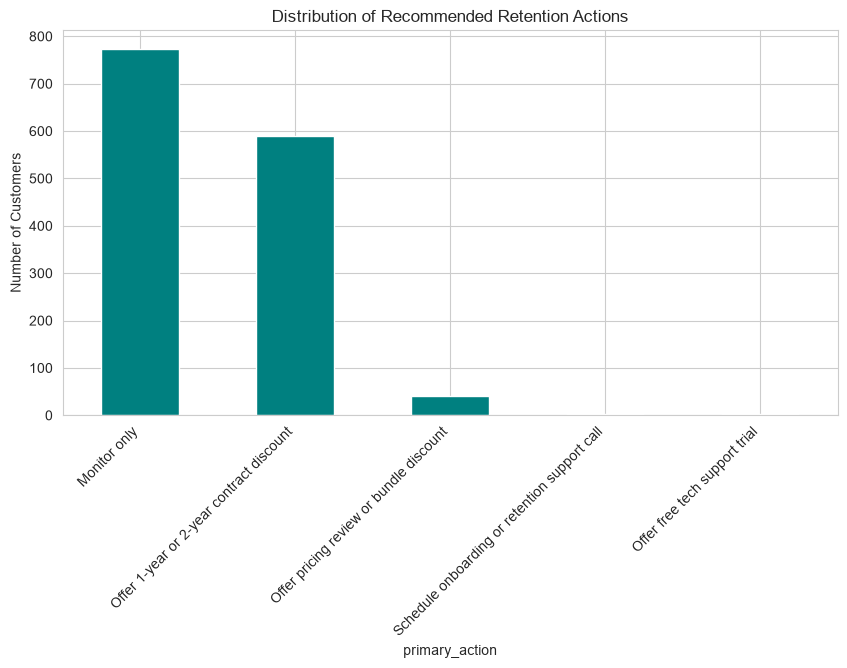

In [722]:
test_results["primary_action"].value_counts().plot(kind="bar", figsize=(10,5), color="teal")
plt.title("Distribution of Recommended Retention Actions")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.show()

**A rule-based retention recommendation layer was built on top of the final churn model. Customers were first segmented by predicted churn probability into low, medium, and high risk groups. Then business rules based on EDA findings and important churn drivers were used to recommend retention actions such as contract discounts, pricing offers, onboarding calls, and support trials. This layer converts churn prediction into actionable business decision support.**

## scenario-based business simulation.

In [723]:
offer_cost = 100
retention_success_rate = 0.20
months_saved = 12

In [724]:
target_group = test_results[test_results["risk_segment"] == "High"].copy()
target_group.shape

(345, 26)

In [725]:
num_targeted = len(target_group)
num_actual_churners_captured = target_group["true_churn"].sum()
total_actual_churners = test_results["true_churn"].sum()

precision_targeting = num_actual_churners_captured / num_targeted if num_targeted > 0 else 0
recall_targeting = num_actual_churners_captured / total_actual_churners if total_actual_churners > 0 else 0

print("Customers targeted:", num_targeted)
print("Actual churners captured:", num_actual_churners_captured)
print("Targeting precision:", round(precision_targeting, 4))
print("Targeting recall:", round(recall_targeting, 4))

Customers targeted: 345
Actual churners captured: 215
Targeting precision: 0.6232
Targeting recall: 0.5749


In [726]:
target_group["estimated_customer_value"] = target_group["MonthlyCharges"] * months_saved

In [727]:
avg_customer_value = target_group["estimated_customer_value"].mean()
print("Average estimated customer value:", round(avg_customer_value, 2))

Average estimated customer value: 922.21


In [728]:
estimated_saved_customers = num_actual_churners_captured * retention_success_rate
print("Estimated saved customers:", round(estimated_saved_customers, 2))

Estimated saved customers: 43.0


In [729]:
gross_revenue_saved_detailed = (
    target_group[target_group["true_churn"] == 1]["estimated_customer_value"].sum()
    * retention_success_rate
)
print("Estimated gross revenue saved (detailed):", round(gross_revenue_saved_detailed, 2))

Estimated gross revenue saved (detailed): 39526.32


In [730]:
campaign_cost = num_targeted * offer_cost
print("Campaign cost:", round(campaign_cost, 2))

Campaign cost: 34500


In [731]:
net_benefit = gross_revenue_saved_detailed - campaign_cost
roi = net_benefit / campaign_cost if campaign_cost > 0 else 0

print("Net benefit:", round(net_benefit, 2))
print("ROI:", round(roi, 4))

Net benefit: 5026.32
ROI: 0.1457


In [732]:
print("ROI (%):", round(roi * 100, 2))

ROI (%): 14.57


In [733]:
business_summary = pd.DataFrame({
    "Metric": [
        "Customers targeted",
        "Actual churners captured",
        "Targeting precision",
        "Targeting recall",
        "Estimated saved customers",
        "Average estimated customer value",
        "Estimated gross revenue saved",
        "Campaign cost",
        "Net benefit",
        "ROI (%)"
    ],
    "Value": [
        num_targeted,
        num_actual_churners_captured,
        round(precision_targeting, 4),
        round(recall_targeting, 4),
        round(estimated_saved_customers, 2),
        round(avg_customer_value, 2),
        round(gross_revenue_saved_detailed, 2),
        round(campaign_cost, 2),
        round(net_benefit, 2),
        round(roi * 100, 2)
    ]
})

business_summary

,Metric,Value
0,Customers targeted,345.0000
1,Actual churners captured,215.0000
2,Targeting precision,0.6232
3,Targeting recall,0.5749
4,Estimated saved customers,43.0000
5,Average estimated customer value,922.2100
6,Estimated gross revenue saved,39526.3200
7,Campaign cost,34500.0000
8,Net benefit,5026.3200
9,ROI (%),14.5700


In [734]:
def business_impact(df, group_name, offer_cost=100, retention_success_rate=0.20, months_saved=12):
    temp = df.copy()
    temp["estimated_customer_value"] = temp["MonthlyCharges"] * months_saved

    num_targeted = len(temp)
    actual_churners_captured = temp["true_churn"].sum()
    total_actual_churners = test_results["true_churn"].sum()

    precision_targeting = actual_churners_captured / num_targeted if num_targeted > 0 else 0
    recall_targeting = actual_churners_captured / total_actual_churners if total_actual_churners > 0 else 0

    avg_customer_value = temp["estimated_customer_value"].mean() if num_targeted > 0 else 0
    estimated_saved_customers = actual_churners_captured * retention_success_rate
    gross_revenue_saved = estimated_saved_customers * avg_customer_value
    campaign_cost = num_targeted * offer_cost
    net_benefit = gross_revenue_saved - campaign_cost
    roi = net_benefit / campaign_cost if campaign_cost > 0 else 0

    return pd.DataFrame([{
        "Target Group": group_name,
        "Customers Targeted": num_targeted,
        "Churners Captured": actual_churners_captured,
        "Precision": round(precision_targeting, 4),
        "Recall": round(recall_targeting, 4),
        "Est. Saved Customers": round(estimated_saved_customers, 2),
        "Gross Revenue Saved": round(gross_revenue_saved_detailed, 2),
        "Campaign Cost": round(campaign_cost, 2),
        "Net Benefit": round(net_benefit, 2),
        "ROI (%)": round(roi * 100, 2)
    }])

In [735]:
high_group = test_results[test_results["risk_segment"] == "High"]
medium_high_group = test_results[test_results["risk_segment"].isin(["High", "Medium"])]

impact_high = business_impact(high_group, "High Risk Only")
impact_medium_high = business_impact(medium_high_group, "High + Medium Risk")

pd.concat([impact_high, impact_medium_high], ignore_index=True)

,Target Group,Customers Targeted,Churners Captured,Precision,Recall,Est. Saved Customers,Gross Revenue Saved,Campaign Cost,Net Benefit,ROI (%)
0,High Risk Only,345,215,0.6232,0.5749,43.0,39526.32,34500,5154.90,14.94
1,High + Medium Risk,635,309,0.4866,0.8262,61.8,39526.32,63500,-9165.01,-14.43


**A simple business impact analysis was conducted to estimate the practical value of the churn model. High-risk customers were treated as the primary campaign target group. Since the dataset does not include actual campaign costs or customer lifetime value, a scenario-based approach was used with explicit assumptions for retention success rate, offer cost, and customer value. This analysis helps translate model performance into operational metrics such as customers targeted, churners captured, estimated revenue saved, and campaign ROI.**

- This is a simulated business impact
- It depends on assumptions
- It is not actual observed retention revenue
- Real deployment would require A/B testing or uplift modeling

In [736]:
from sklearn.pipeline import Pipeline
import joblib
import os

churn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", weighted_xgb)
])

churn_pipeline.fit(X_train, y_train)

os.makedirs("models", exist_ok=True)
joblib.dump(churn_pipeline, "models/churn_pipeline.pkl")

print("Pipeline saved successfully to models/churn_pipeline.pkl")

Pipeline saved successfully to models/churn_pipeline.pkl


In [ ]:
loaded_pipeline = joblib.load("models/churn_pipeline.pkl")
loaded_pipeline.predict(X_test.head(3))
loaded_pipeline.predict_proba(X_test.head(3))

array([[0.98792917, 0.01207084],
       [0.05681193, 0.9431881 ],
       [0.79924726, 0.20075272]], dtype=float32)

: 